## Import

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
data_exp = pd.read_excel('sheet_full_environment_experiments.xlsx', sheet_name='Sheet1')
data_sumo_rl = pd.read_excel("SUMO-RL-EXP.xlsx")



In [ ]:
data_exp.head(-4)

,Area,Reward,Environment Type,Algorithm,Episodes,Max Sumo Steps(s),Traffic Scale,Seed,Runned By,Reward of Last Episode,...,Total Time Of Training (M),Reward on Final Test,Waiting Time (s) on Final Test,Speed (m/s) on Final Test,Depart Delay (s) on Final Test,Time Loss (s) on Final Test,Waiting Car on Final Test,Device,Notes,Study Group
0,Area2 (Mosheer Ismail),Literature,GroupedSumoEnv,D3QN,350,3000,Normal (.14),0,NaN,4.500000,...,3.257,-14.110688,1463.89,4.97,28.63,1856.25,26,colab,NaN,NaN
1,Area2 (Mosheer Ismail),Literature,GroupedSumoEnv,D3QN,350,3000,Normal (.14),1,NaN,4.500000,...,3.338,-25.021125,928.61,6.93,63.33,1080.99,20,colab,NaN,NaN
2,Area2 (Mosheer Ismail),Literature,GroupedSumoEnv,D3QN,350,3000,Normal (.14),2,NaN,4.213000,...,2.507,21.013125,133.25,7.82,15.63,583.49,27,colab,NaN,NaN
3,Area2 (Mosheer Ismail),Literature,GroupedSumoEnv,D3QN,350,3000,Normal (.14),3,NaN,11.100000,...,3.189,35.562750,760.69,4.89,16.00,1461.44,1,colab,NaN,NaN
4,Area2 (Mosheer Ismail),Literature,GroupedSumoEnv,D3QN,350,3000,Crowding (.38),0,NaN,5.863000,...,6.742,14.204438,1423.89,5.28,55.73,1582.27,38,colab,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,Bench(2waySingle),Literature,HighGroupedSumoEnv,dqn,1,3000,Default (0),3,NaN,-923464.312500,...,3.229,0.000000,0.00,0.00,0.00,0.00,0,colab,NaN,NaN
136,Bench(2waySingle),Proposed,GroupedSumoEnv,dqn,1,3000,Default (0),0,NaN,-59090.507812,...,5.435,0.000000,0.00,0.00,0.00,0.00,0,colab,NaN,NaN
137,Bench(2waySingle),Proposed,GroupedSumoEnv,dqn,1,3000,Default (0),1,NaN,-62436.968750,...,5.875,0.000000,0.00,0.00,0.00,0.00,0,colab,NaN,NaN
138,Bench(2waySingle),Proposed,GroupedSumoEnv,dqn,1,3000,Default (0),2,NaN,-63739.707031,...,5.756,0.000000,0.00,0.00,0.00,0.00,0,colab,NaN,NaN


In [ ]:
# Run this cell once
data_sumo_rl = data_sumo_rl.drop(['Device', 'Notes', 'Study Group'],axis = 1)
data_exp =  data_exp.drop(['Device', 'Notes', 'Study Group'],axis = 1)

## Helper Functions

In [ ]:
def get_grouped_seed(data):
    group_cols = ['Area', 'Reward', 'Algorithm', 'Traffic Scale']

    if 'Environment Type' in data.columns:
        group_cols.append('Environment Type')

    #numeric_cols = data.select_dtypes(include='number').columns

    result = (
        data
        .groupby(group_cols)
        .mean()
        .reset_index()
    )
    return result



In [ ]:
#pip install nbformat>=4.2.0
#pip install seaborn

In [ ]:
def plot_with_benchmark(
    data_exp, 
    data_bench_groubed, 
    area, 
    column_y, 
    reward='Proposed', 
    reward_sumo = "Default"
):

    # Filter benchmark data
    data_bench_groubed = data_bench_groubed[data_bench_groubed['Area'] == area]

    column_x = 'Traffic Scale'

    # Filter experimental data for the selected reward
    data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area] 

    # --- Create FacetGrid ---
    g = sns.FacetGrid(
        data_exp_filtered,
        col="Algorithm",
        row="Environment Type",
       # hue="Reward",
        margin_titles=True,
        height=4,
        aspect=2
    )

    # --- Boxplot per x-axis point ---
    def boxplot_per_x(data, **kwargs):
        ax = plt.gca()
        grouped = data.groupby(column_x)[column_y]

        x_labels = sorted(grouped.groups.keys())
        box_data = [grouped.get_group(x).values for x in x_labels]
        x_positions = range(len(x_labels))

        ax.boxplot(
            box_data,
            positions=x_positions,
            widths=0.25,
            showfliers=False,
            patch_artist=True
        )

        ax.set_xticks(x_positions)
        ax.set_xticklabels(x_labels)
        ax.set_ylabel(column_y)

    g.map_dataframe(boxplot_per_x)

    
    # --- Add benchmark points for the specified reward ---
    for ax, (env, algo) in zip(
        g.axes.flat,
        [(e, a) for e in data_exp_filtered["Environment Type"].unique()
               for a in data_exp_filtered["Algorithm"].unique()]
    ):
        subset_bench = data_bench_groubed[
            (data_bench_groubed['Algorithm'] == algo) &
            (data_bench_groubed['Reward'] == reward_sumo)
        ]


        if not subset_bench.empty:
            ax.scatter(
                subset_bench[column_x],
                subset_bench[column_y],
                color='purple',
                marker='$-$',
                s=3500,
                linewidth=1.5,
                label=f"Benchmark {reward_sumo}",
                zorder=10
            )

    # --- Formatting ---
    g.add_legend()
    g.figure.suptitle(
        f"Performance Comparison (Using Reward : {reward})\n{column_y} on area {area}",
        fontsize=16,y=1.1
    )
    g.figure.tight_layout(rect=[0, 0, 1, 2.1])
    g.figure.subplots_adjust(top=0.9)
    plt.show()


## Plots 

In [ ]:
data_bench_grouped = get_grouped_seed(data_sumo_rl)

In [ ]:
data_exp[data_exp['Reward'] == 'Proposed'][data_exp['Area'] == "Bench(2waySingle)"][data_exp["Traffic Scale"]=="Default (0)"]

C:\Users\LapStore\AppData\Local\Temp\ipykernel_1720\1125067131.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp[data_exp['Reward'] == 'Proposed'][data_exp['Area'] == "Bench(2waySingle)"][data_exp["Traffic Scale"]=="Default (0)"]
C:\Users\LapStore\AppData\Local\Temp\ipykernel_1720\1125067131.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp[data_exp['Reward'] == 'Proposed'][data_exp['Area'] == "Bench(2waySingle)"][data_exp["Traffic Scale"]=="Default (0)"]


,Area,Reward,Environment Type,Algorithm,Episodes,Max Sumo Steps(s),Traffic Scale,Seed,Runned By,Reward of Last Episode,...,Depart Delay (s),Time Loss (s),Waiting Car,Total Time Of Training (M),Reward on Final Test,Waiting Time (s) on Final Test,Speed (m/s) on Final Test,Depart Delay (s) on Final Test,Time Loss (s) on Final Test,Waiting Car on Final Test
168,Bench(2waySingle),Proposed,GroupedSumoEnv,dqn,1,3000,Default (0),0,NaN,-60676.617188,...,109.05,182.16,161,3.688,0.0,0.0,0.0,0.0,0.0,0
169,Bench(2waySingle),Proposed,GroupedSumoEnv,dqn,1,3000,Default (0),1,NaN,-65588.773438,...,93.97,178.69,188,3.940,0.0,0.0,0.0,0.0,0.0,0
170,Bench(2waySingle),Proposed,GroupedSumoEnv,dqn,1,3000,Default (0),2,NaN,-60797.039062,...,101.77,170.45,147,3.734,0.0,0.0,0.0,0.0,0.0,0
171,Bench(2waySingle),Proposed,GroupedSumoEnv,dqn,1,3000,Default (0),3,NaN,-51580.949219,...,99.40,171.05,117,3.283,0.0,0.0,0.0,0.0,0.0,0
172,Bench(2waySingle),Proposed,HighGroupedSumoEnv,dqn,1,3000,Default (0),0,NaN,-77890.968750,...,110.92,245.69,188,4.902,0.0,0.0,0.0,0.0,0.0,0
173,Bench(2waySingle),Proposed,HighGroupedSumoEnv,dqn,1,3000,Default (0),1,NaN,-79950.554688,...,130.18,221.99,188,4.835,0.0,0.0,0.0,0.0,0.0,0
174,Bench(2waySingle),Proposed,HighGroupedSumoEnv,dqn,1,3000,Default (0),2,NaN,-81463.468750,...,145.48,216.75,188,4.898,0.0,0.0,0.0,0.0,0.0,0
175,Bench(2waySingle),Proposed,HighGroupedSumoEnv,dqn,1,3000,Default (0),3,NaN,-80843.773438,...,142.49,208.96,172,4.909,0.0,0.0,0.0,0.0,0.0,0


C:\Users\LapStore\AppData\Local\Temp\ipykernel_18780\3986548013.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


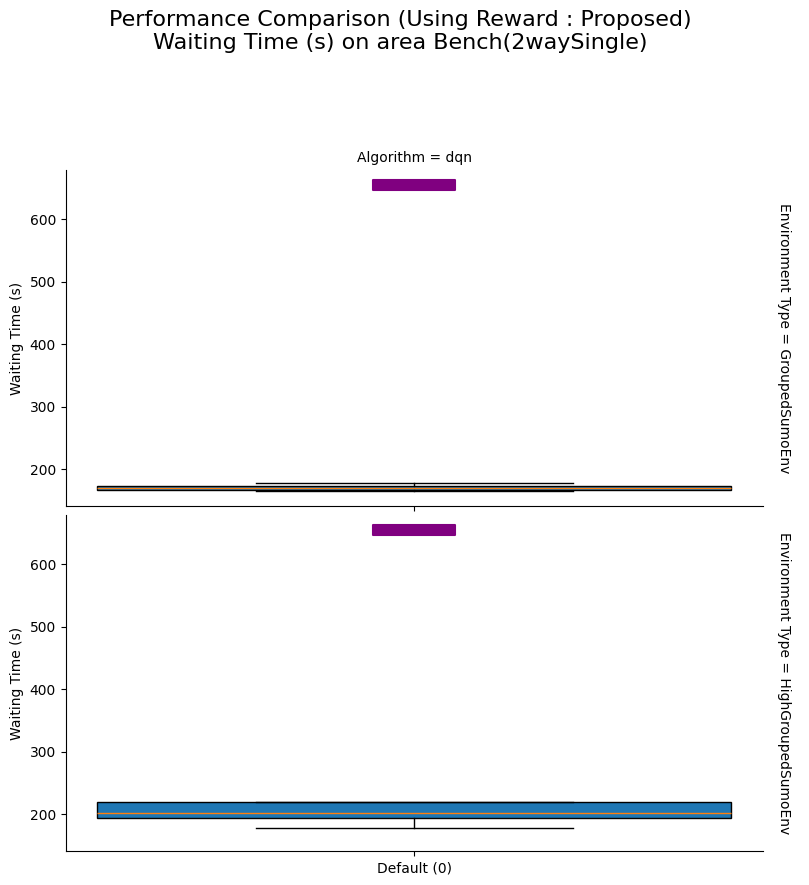

None


C:\Users\LapStore\AppData\Local\Temp\ipykernel_18780\3986548013.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


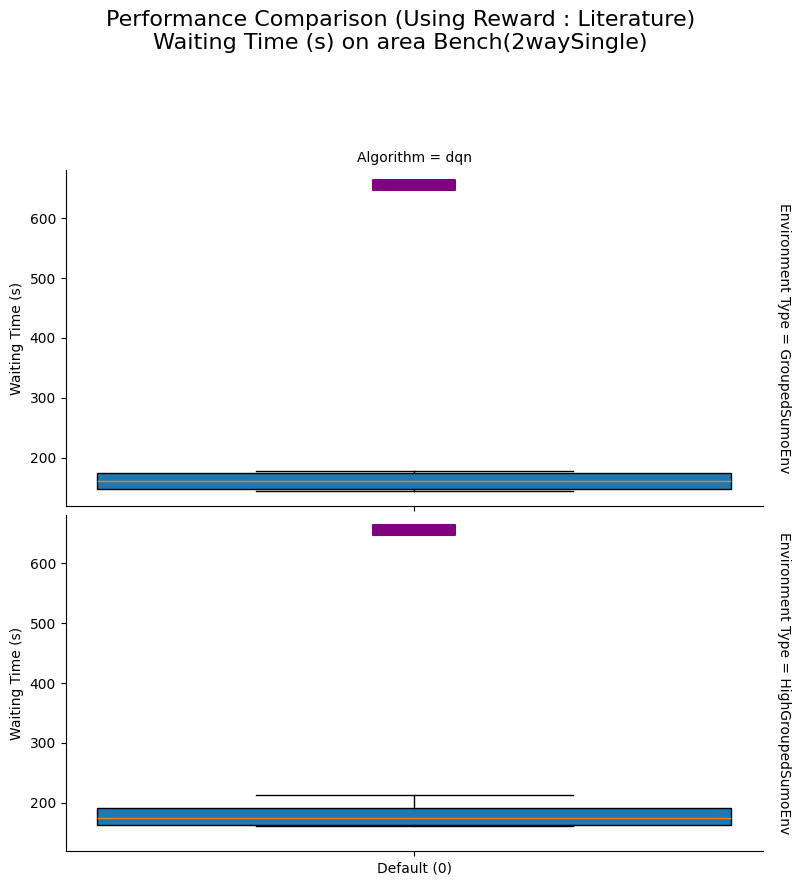

None


C:\Users\LapStore\AppData\Local\Temp\ipykernel_18780\3986548013.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


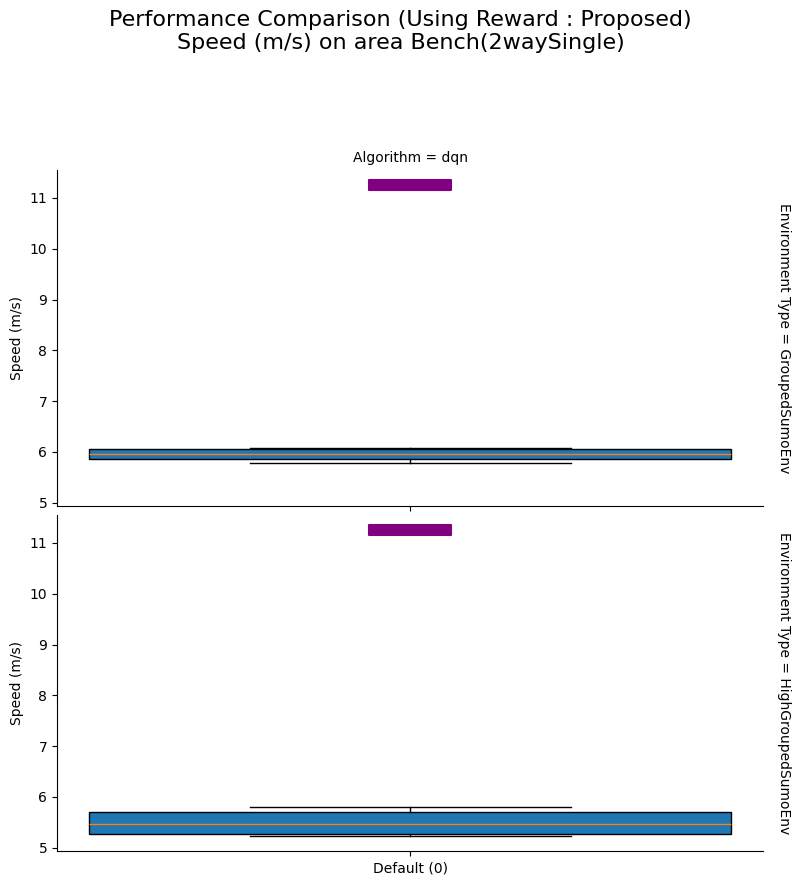

None


C:\Users\LapStore\AppData\Local\Temp\ipykernel_18780\3986548013.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


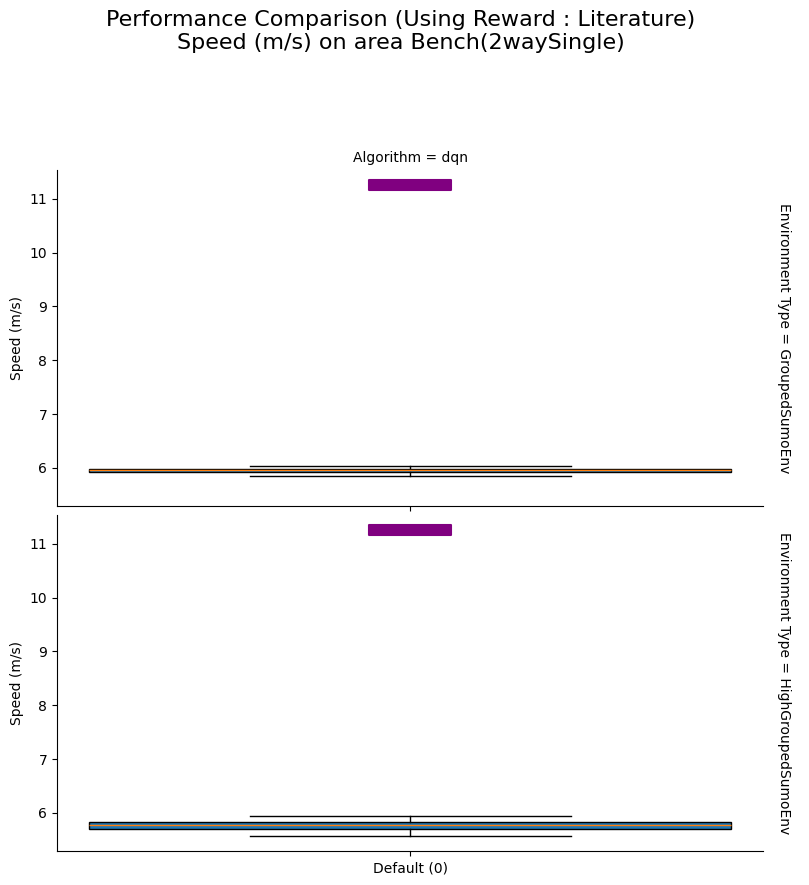

None


C:\Users\LapStore\AppData\Local\Temp\ipykernel_18780\3986548013.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


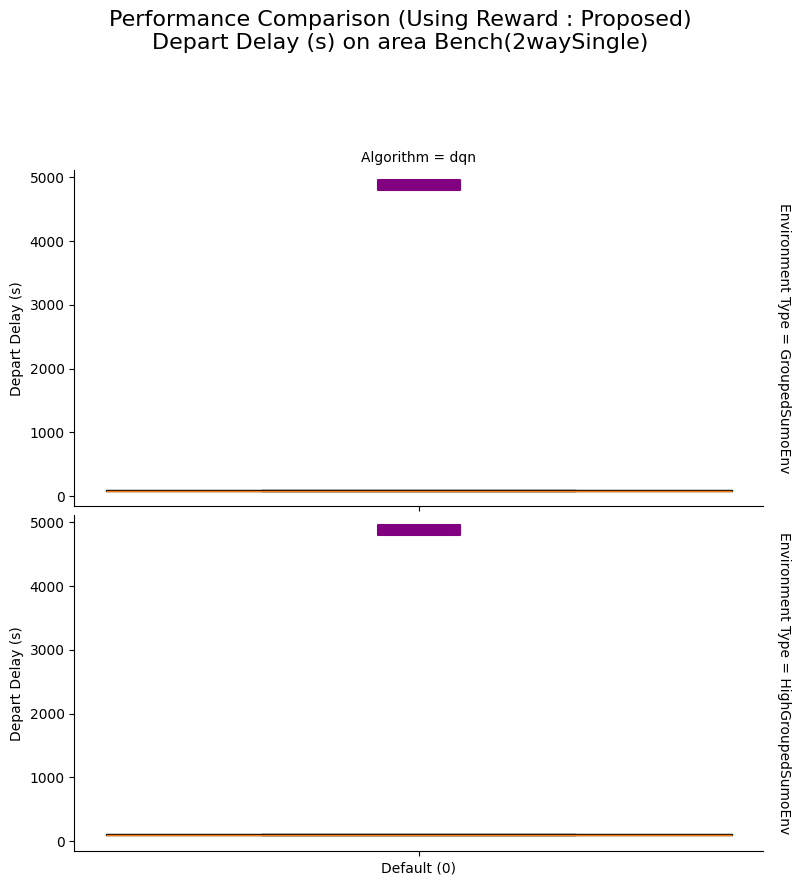

None


C:\Users\LapStore\AppData\Local\Temp\ipykernel_18780\3986548013.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


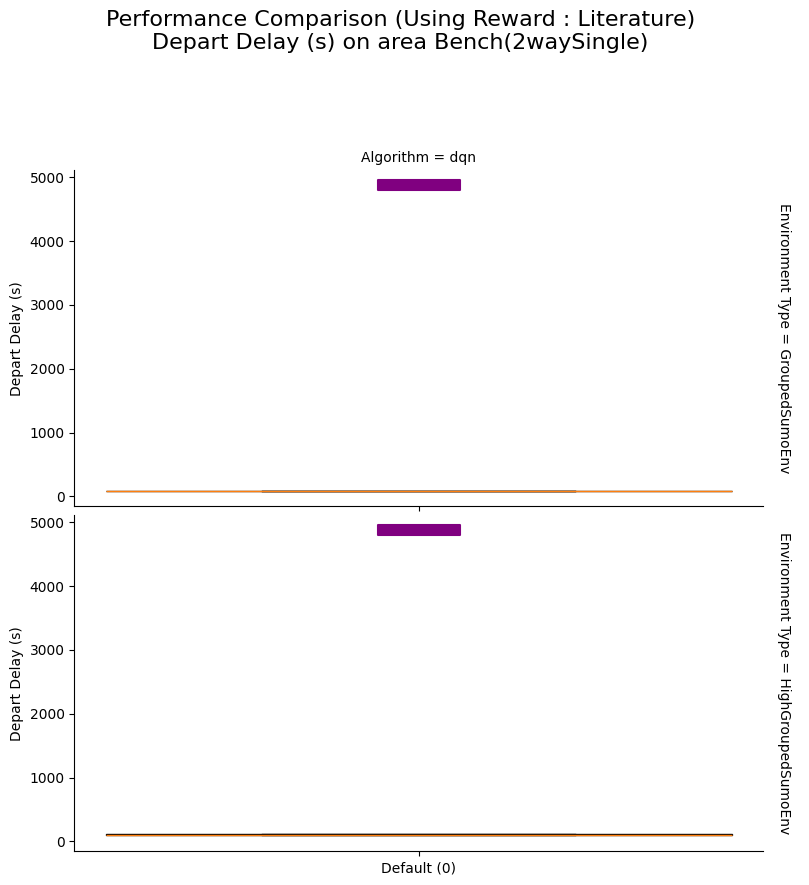

None


C:\Users\LapStore\AppData\Local\Temp\ipykernel_18780\3986548013.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


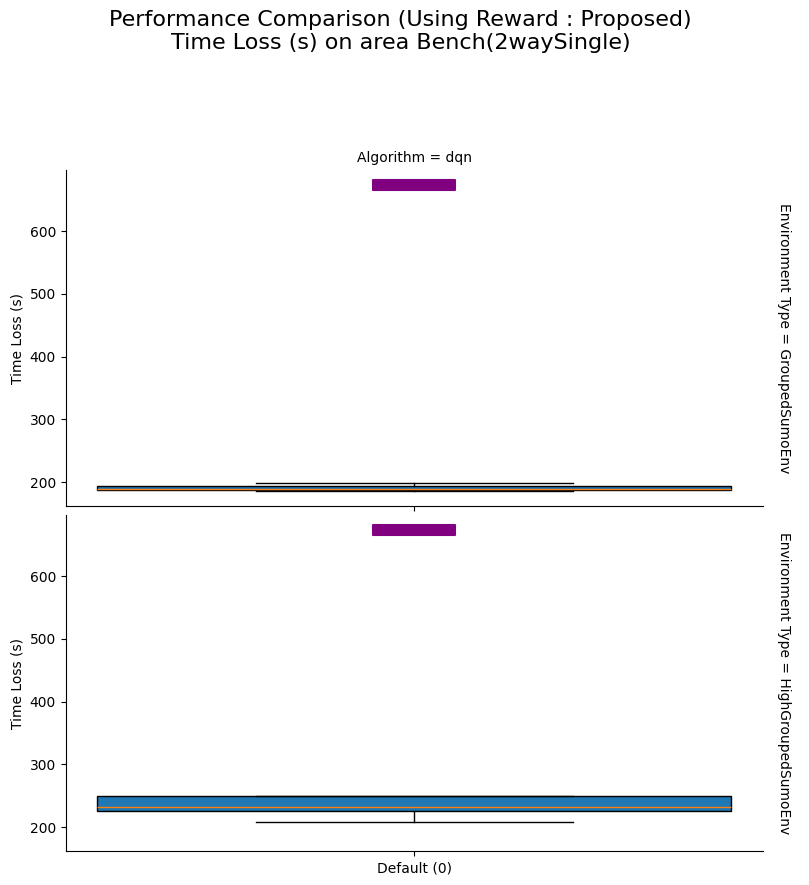

None


C:\Users\LapStore\AppData\Local\Temp\ipykernel_18780\3986548013.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


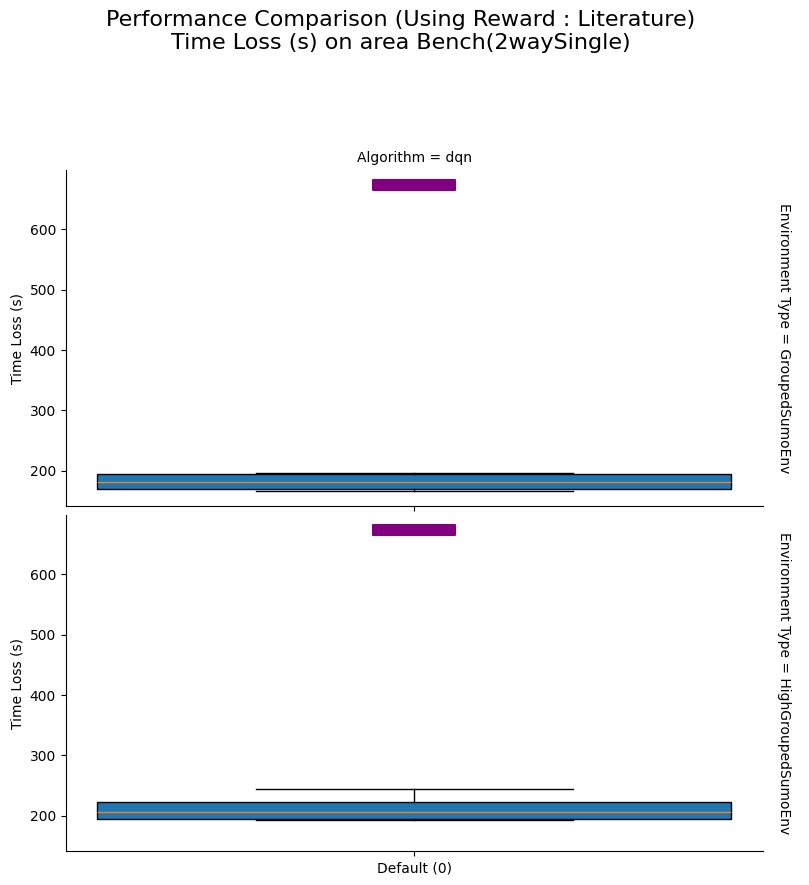

None


C:\Users\LapStore\AppData\Local\Temp\ipykernel_18780\3986548013.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


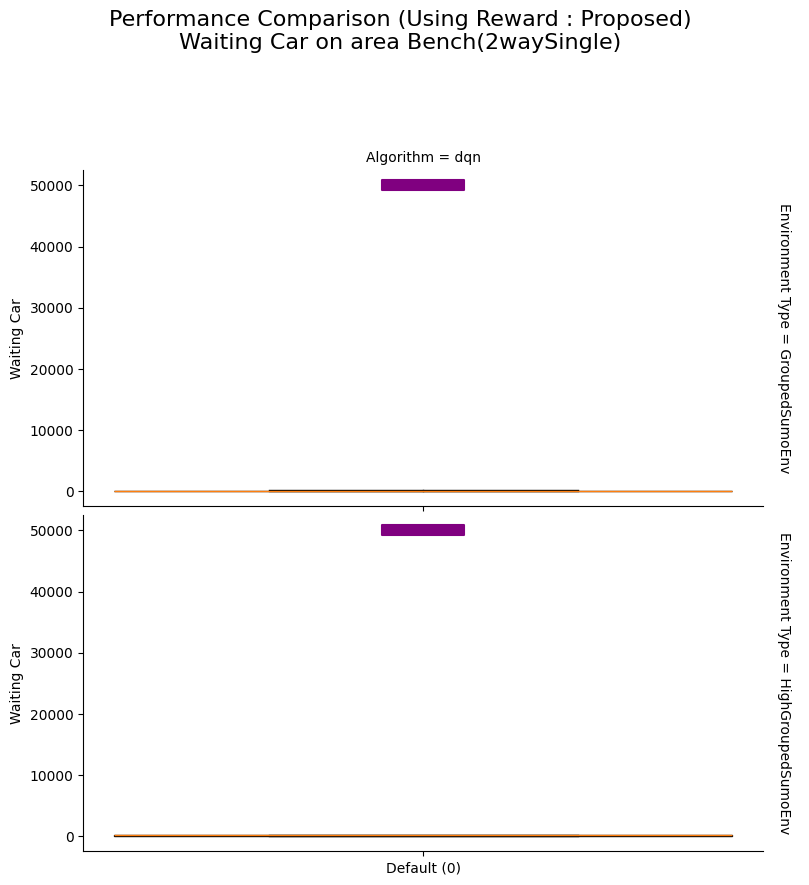

None


C:\Users\LapStore\AppData\Local\Temp\ipykernel_18780\3986548013.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


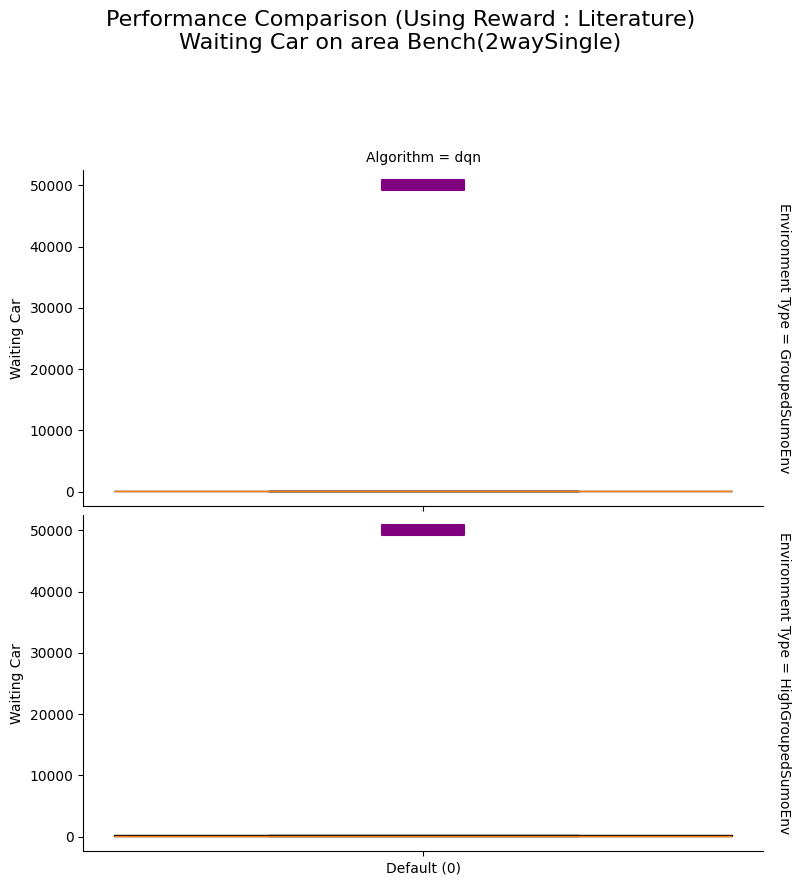

None


C:\Users\LapStore\AppData\Local\Temp\ipykernel_18780\3986548013.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


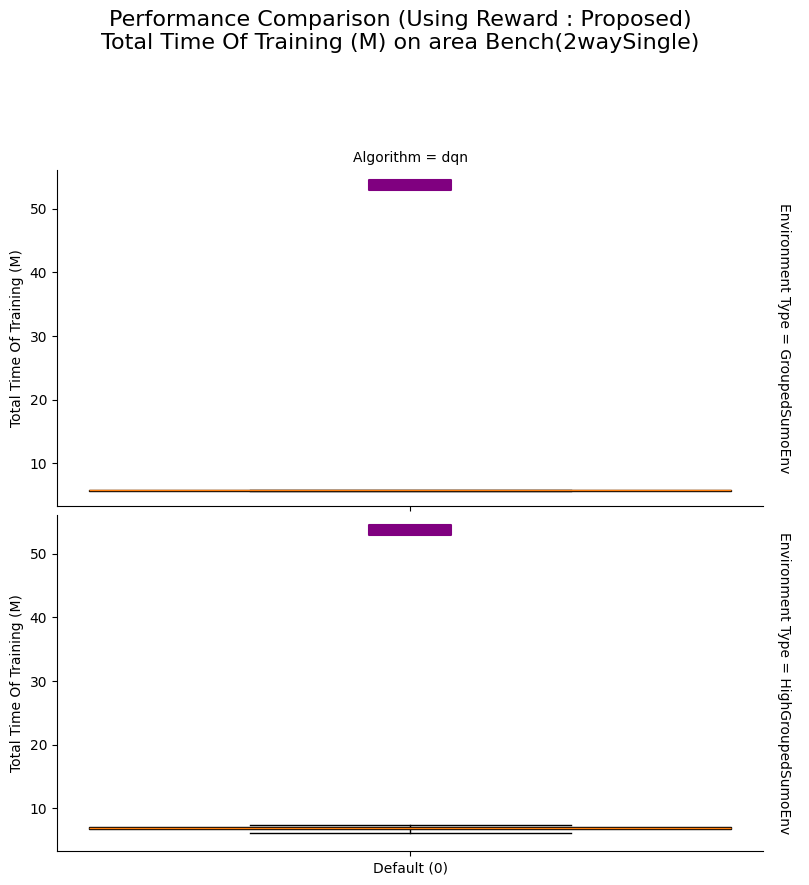

None


C:\Users\LapStore\AppData\Local\Temp\ipykernel_18780\3986548013.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


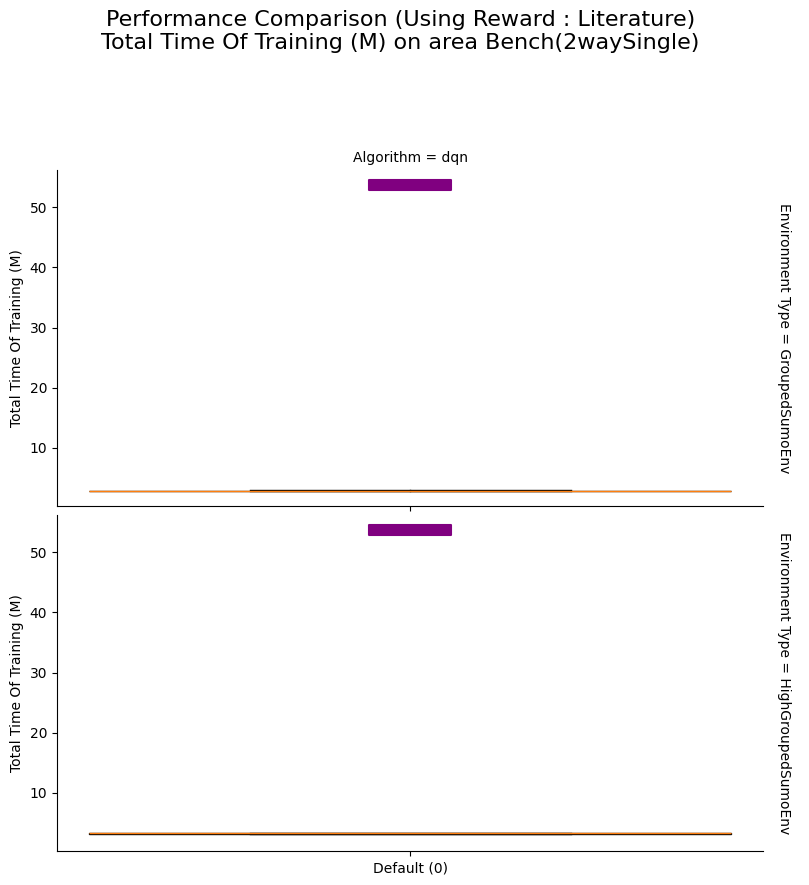

None


In [ ]:
for metric in ['Waiting Time (s)', 'Speed (m/s)',
       'Depart Delay (s)', 'Time Loss (s)', 'Waiting Car',
       'Total Time Of Training (M)']:
    for reward_ in ['Proposed','Literature']:
         print(plot_with_benchmark(data_exp[data_exp["Traffic Scale"]=="Default (0)"],data_bench_grouped[data_bench_grouped["Traffic Scale"]=="Default (0)"],"Bench(2waySingle)",metric,reward= reward_,reward_sumo = "Default"))
         
    

    

## Anova

In [ ]:
import pandas as pd
from scipy.stats import ttest_ind, f_oneway

def simple_stat_test(df, metric, group_col):
    groups = df[group_col].unique() ##note should each group have data length > 1
    data = [df[df[group_col] == g][metric] for g in groups]
    
    if len(groups) == 2:
        stat, p = ttest_ind(*data)
        #print(f"T-test between {groups[0]} and {groups[1]}: p = {p:.4f}")
        return p 
    elif len(groups) > 2:
        stat, p = f_oneway(*data)
        #print(f"ANOVA across groups in '{group_col}': p = {p:.4f}")
        return p
    else:
        
        #print("Not enough groups to test.")
        return -1
    return -1
#tukey = pairwise_tukeyhsd(endog=df["Reward"], groups=df["Algorithm"], alpha=0.05)



In [ ]:
alpha = .03

In [ ]:
from tabulate import tabulate
from colorama import Fore, Style

data_exp= data_exp[data_exp['Algorithm']=='dqn'][data_exp["Traffic Scale"]=="Default (0)"][data_exp["Area"]=="Bench(2waySingle)"]
headers = ["Area", "Reward", "Traffic Scale", "Algorithm", 'Reward of Last Episode','Waiting Time (s)','Speed (m/s)', 'Depart Delay (s)', 'Time Loss (s)', 'Waiting Car']
table_data = []

for Algorithm in set(data_exp['Algorithm'].values):
    for scale in set(data_exp['Traffic Scale'].values):
        for Reward in set(data_exp['Reward'].values):
            for Area in set(data_exp['Area'].values):
                analysis_mask = (
                    (data_exp['Area'] == Area) &
                    (data_exp['Reward'] == Reward) &
                    (data_exp['Traffic Scale'] ==scale) &
                    (data_exp['Algorithm'] == Algorithm) 
                )

                data_i_exp = data_exp[analysis_mask]
            

                reward_test = simple_stat_test(data_i_exp, "Average Reward for Evaluated Episodes With Same Time","Environment Type") 
                reward_color = Fore.RED if reward_test < alpha else Fore.GREEN

                waiting_test = simple_stat_test(data_i_exp, "Waiting Time (s)","Environment Type") 
                waiting_color = Fore.RED if waiting_test<alpha else Fore.GREEN

                spd_test = simple_stat_test(data_i_exp, 'Speed (m/s)',"Environment Type") 
                spd_color = Fore.RED if spd_test<alpha else Fore.GREEN

                depart_test = simple_stat_test(data_i_exp,'Depart Delay (s)',"Environment Type") 
                depart_color = Fore.RED if depart_test < alpha else Fore.GREEN

                Tloss_test = simple_stat_test(data_i_exp,'Time Loss (s)',"Environment Type") 
                Tloss_color = Fore.RED if Tloss_test < alpha else Fore.GREEN

                carWait_test = simple_stat_test(data_i_exp, 'Waiting Car',"Environment Type") 
                carWait_color = Fore.RED if carWait_test < alpha else Fore.GREEN

                table_data.append([
                        f"{Fore.CYAN} {Area} {Style.RESET_ALL}",
                        f"{Fore.CYAN} {Reward} {Style.RESET_ALL}",
                        f"{Fore.CYAN} {scale} {Style.RESET_ALL}",
                        f"{Fore.CYAN} {Algorithm} {Style.RESET_ALL}",
                        f"{reward_color} {reward_test} {Style.RESET_ALL}",
                        f"{waiting_color}{waiting_test}{Style.RESET_ALL}",
                        f"{spd_color}{spd_test}{Style.RESET_ALL}",
                        f"{depart_color}{depart_test}{Style.RESET_ALL}",
                        f"{Tloss_color}{Tloss_test}{Style.RESET_ALL}",
                        f"{carWait_color}{carWait_test}{Style.RESET_ALL}"

                ])
            

table =tabulate(table_data, headers=headers, tablefmt="grid")

print(table)

+---------------------+--------------+-----------------+-------------+--------------------------+--------------------+---------------+--------------------+-----------------+---------------+
| Area                | Reward       | Traffic Scale   | Algorithm   |   Reward of Last Episode |   Waiting Time (s) |   Speed (m/s) |   Depart Delay (s) |   Time Loss (s) |   Waiting Car |
+=====================+==============+=================+=============+==========================+====================+===============+====================+=================+===============+
|  Bench(2waySingle)  |  Literature  |  Default (0)    |  dqn        |                0.0300306 |          0.229831  |     0.0682587 |        0.000208107 |       0.072813  |     0.160613  |
+---------------------+--------------+-----------------+-------------+--------------------------+--------------------+---------------+--------------------+-----------------+---------------+
|  Bench(2waySingle)  |  Proposed    |  Default (0

C:\Users\LapStore\AppData\Local\Temp\ipykernel_18780\3541003023.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp= data_exp[data_exp['Algorithm']=='dqn'][data_exp["Traffic Scale"]=="Default (0)"][data_exp["Area"]=="Bench(2waySingle)"]
C:\Users\LapStore\AppData\Local\Temp\ipykernel_18780\3541003023.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp= data_exp[data_exp['Algorithm']=='dqn'][data_exp["Traffic Scale"]=="Default (0)"][data_exp["Area"]=="Bench(2waySingle)"]


In [29]:
# Same as above but save to XLSX without colors
import pandas as pd
from tabulate import tabulate
from colorama import Fore, Style

headers = [
    "Area", "Reward", "Traffic Scale", "Algorithm",
    'Reward of Last Episode','Waiting Time (s)','Speed (m/s)',
    'Depart Delay (s)', 'Time Loss (s)', 'Waiting Car'
]

table_data_print = []
table_data_xlsx = []

for Algorithm in set(data_exp['Algorithm'].values):
    for scale in set(data_exp['Traffic Scale'].values):
        for Reward in set(data_exp['Reward'].values):
            for Area in set(data_exp['Area'].values):

                mask = (
                    (data_exp['Area'] == Area) &
                    (data_exp['Reward'] == Reward) &
                    (data_exp['Traffic Scale'] == scale) &
                    (data_exp['Algorithm'] == Algorithm) 
                )
                data_i_exp = data_exp[mask]

                reward_test = simple_stat_test(data_i_exp,"Average Reward for Evaluated Episodes With Same Time","Environment Type")
                waiting_test = simple_stat_test(data_i_exp,"Waiting Time (s)","Environment Type")
                spd_test = simple_stat_test(data_i_exp,'Speed (m/s)',"Environment Type")
                depart_test = simple_stat_test(data_i_exp,'Depart Delay (s)',"Environment Type")
                Tloss_test = simple_stat_test(data_i_exp,'Time Loss (s)',"Environment Type")
                carWait_test = simple_stat_test(data_i_exp,'Waiting Car',"Environment Type")

                reward_color = Fore.RED if reward_test<alpha else Fore.GREEN
                waiting_color = Fore.RED if waiting_test<alpha else Fore.GREEN
                spd_color = Fore.RED if spd_test<alpha else Fore.GREEN
                depart_color = Fore.RED if depart_test<alpha else Fore.GREEN
                Tloss_color = Fore.RED if Tloss_test<alpha else Fore.GREEN
                carWait_color = Fore.RED if carWait_test<alpha else Fore.GREEN

                # Colorful row for terminal
                table_data_print.append([
                    f"{Fore.CYAN}{Area}{Style.RESET_ALL}",
                    f"{Fore.CYAN}{Reward}{Style.RESET_ALL}",
                    f"{Fore.CYAN}{scale}{Style.RESET_ALL}",
                    f"{Fore.CYAN}{Algorithm}{Style.RESET_ALL}",
                    f"{reward_color}{reward_test}{Style.RESET_ALL}",
                    f"{waiting_color}{waiting_test}{Style.RESET_ALL}",
                    f"{spd_color}{spd_test}{Style.RESET_ALL}",
                    f"{depart_color}{depart_test}{Style.RESET_ALL}",
                    f"{Tloss_color}{Tloss_test}{Style.RESET_ALL}",
                    f"{carWait_color}{carWait_test}{Style.RESET_ALL}"
                ])

                # Clean row for Excel
                table_data_xlsx.append([
                    Area, Reward, scale, Algorithm,
                    reward_test, waiting_test, spd_test,
                    depart_test, Tloss_test, carWait_test
                ])

# Print table
print(tabulate(table_data_print, headers=headers, tablefmt="grid"))

# Save XLSX
df = pd.DataFrame(table_data_xlsx, columns=headers)
df.to_excel("analysis_anova_bench.xlsx", index=False)


+-------------------+------------+-----------------+-------------+--------------------------+--------------------+---------------+--------------------+-----------------+---------------+
| Area              | Reward     | Traffic Scale   | Algorithm   |   Reward of Last Episode |   Waiting Time (s) |   Speed (m/s) |   Depart Delay (s) |   Time Loss (s) |   Waiting Car |
+===================+============+=================+=============+==========================+====================+===============+====================+=================+===============+
| Bench(2waySingle) | Literature | Default (0)     | dqn         |                0.0300306 |          0.229831  |     0.0682587 |        0.000208107 |       0.072813  |     0.160613  |
+-------------------+------------+-----------------+-------------+--------------------------+--------------------+---------------+--------------------+-----------------+---------------+
| Bench(2waySingle) | Proposed   | Default (0)     | dqn         |    

## Conclusion

- The proposed environment achieved lower waiting time and time loss; however, this improvement was associated with a reduction in average vehicle speed.
- The grouped environment demonstrated greater stability, particularly in terms of variance and randomness
- No statistically significant difference was observed between the environments with respect to the reward metric.